<a href="https://colab.research.google.com/github/Sina-Haz/fastai-kaggle/blob/main/Vision_Classification_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Computer Vision for Classification pt. 2

Today we look to make some improvements on our first attempt and we will see how these attempts translate into better test scores via kaggle submission

In [1]:
# Let's do some quick setup first
! pip install -Uq fastkaggle

In [2]:
from fastkaggle import *
import os

os.environ['KAGGLE_USERNAME'] = 'shazeghi'
os.environ['KAGGLE_KEY'] = '87607fda13bdf94dc22bbf70ef2383fb'

comp = 'paddy-disease-classification'
path = setup_comp(comp, install='')

Since we want to iterate fast, another thing we can do is recreate a resized, smaller version of our training set so it's faster to load and read the images to send to our model

In [3]:
from fastai.vision.all import *

In [4]:
# new train path with smaller images:
trn_path = Path('sml')

# Use fastai resize images to take all original train images read, resize and then send to dest folder
resize_images(path/'train_images', dest=trn_path, max_size=224, recurse=True) # use recurse to get same folder structure

Want to experiment with different image preprocessing transforms and architectures

In [5]:
# define a quick fastai training loop we can customize
def train(arch, itm_tfms, btch_tfms, epochs=5):
  dls = ImageDataLoaders.from_folder(trn_path, valid_pct=0.2, item_tfms=itm_tfms, batch_tfms=btch_tfms)
  learner = vision_learner(dls, arch, metrics=error_rate, pretrained=True).to_fp16()
  learner.fine_tune(epochs, 0.01) # use the learning rate we found from last time even though was for resnet model
  return learner

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/64.1M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,1.813444,1.373839,0.421913,00:26


epoch,train_loss,valid_loss,error_rate,time
0,1.192949,0.882629,0.278232,00:27
1,0.812044,0.583640,0.177319,00:27
2,0.603457,0.459806,0.140317,00:28


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

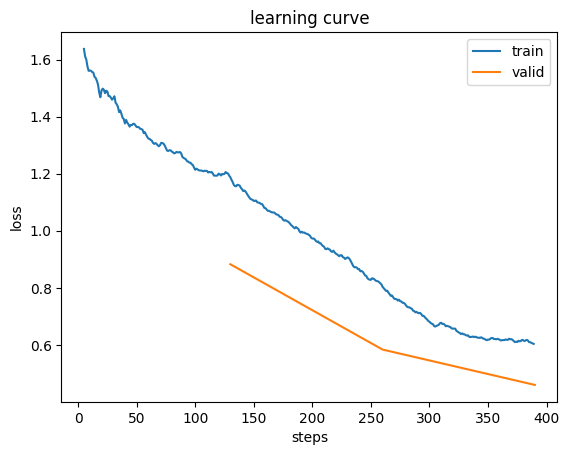

In [6]:
# let's see training speed for previous model
learner = train('resnet26', itm_tfms=Resize(192, method='squish'),
                btch_tfms=aug_transforms(size=128, min_scale=0.75), epochs=3)

# time went from about a minute per epoch to 30ish seconds so great improvement, accuracy isn't affected much either
learner.recorder.plot_loss()

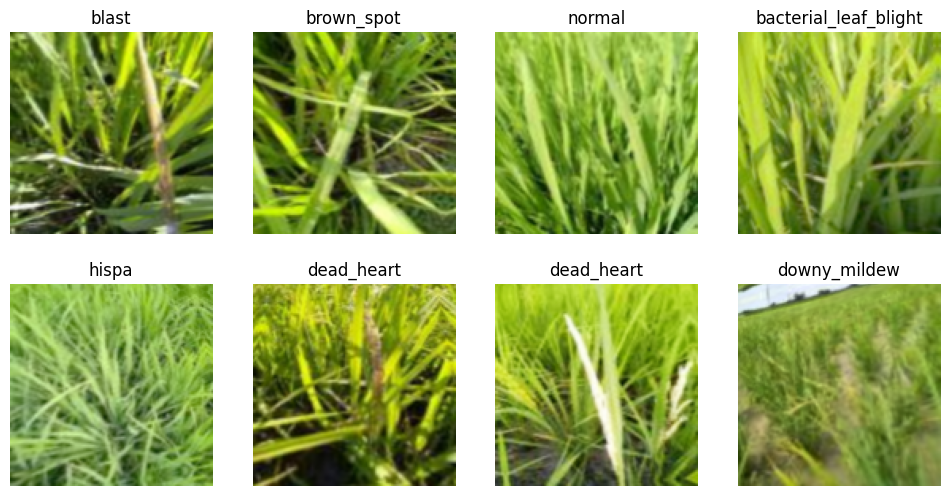

In [9]:
# pretty low res, maybe later we can experiment with how much resolution and # pixels affect performance
learner.dls.show_batch(max_n=8)

### ConvNext Model

Since even with smaller training images we need to wait mostly for CPU reading the image -> use a larger and better architecture such as the convnext

In [10]:
arch='convnext_small_in22k'

# This model takes a bit longer to train but is way more accurate and needs fewer epochs too
conv_learner = train(arch, itm_tfms=Resize(192, method='squish'),
                btch_tfms=aug_transforms(size=128, min_scale=0.75), epochs=3)

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.430730,0.898284,0.291206,00:35


epoch,train_loss,valid_loss,error_rate,time
0,0.723554,0.563600,0.186449,00:46
1,0.456257,0.314679,0.101874,00:41
2,0.266727,0.222060,0.069197,00:38


### Experiment 1: Trying different image resizing

Now that we've seen that the convnext model is superior let's see how different methods for item transforms and resizing affect our model training

In [11]:
# Previously we used squish, now let's try with cropping
conv_learner2 = train(arch, itm_tfms=Resize(192), # default resize method is crop
                btch_tfms=aug_transforms(size=128, min_scale=0.75), epochs=3)

epoch,train_loss,valid_loss,error_rate,time
0,1.489970,0.965940,0.306583,00:32


epoch,train_loss,valid_loss,error_rate,time
0,0.846604,0.664448,0.203748,00:40
1,0.563342,0.344020,0.110524,00:39
2,0.338305,0.263168,0.082172,00:39


In [12]:
# Now let's try with padding - doesn't distort or cut out any image information
# but now we have 0 pixels that essentially don't affect our predictions

conv_learner3 = train(arch, itm_tfms=Resize(192, pad_mode='zeros', method = ResizeMethod.Pad),
                btch_tfms=aug_transforms(size=128, min_scale=0.75), epochs=3)

epoch,train_loss,valid_loss,error_rate,time
0,1.572617,1.080128,0.346468,00:32


epoch,train_loss,valid_loss,error_rate,time
0,0.815282,0.556755,0.180202,00:36
1,0.535166,0.321541,0.107641,00:36
2,0.287466,0.255114,0.080250,00:37


#### Conclusions:
 - Cropping seems to be a little worse than squishing
 - Padding is also a little worse
 - Overall though, it didn't affect our results by much


 ### Next Experiment: Test Time Augmentation (TTA)
  - Perhaps certain orientations/brightness/etc. make it easier for our model to make correct predictions
  - Can take 1 image -> augment it X different ways, then predict on all of them and get the average
  - Like a mini-bagging approach

In [13]:
# To get a baseline let's see our models prediction and error rate w/o TTA

val = conv_learner.dls.valid

preds, targs = conv_learner.get_preds(dl=val)

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


In [14]:
error_rate(preds, targs)

TensorBase(0.0692)

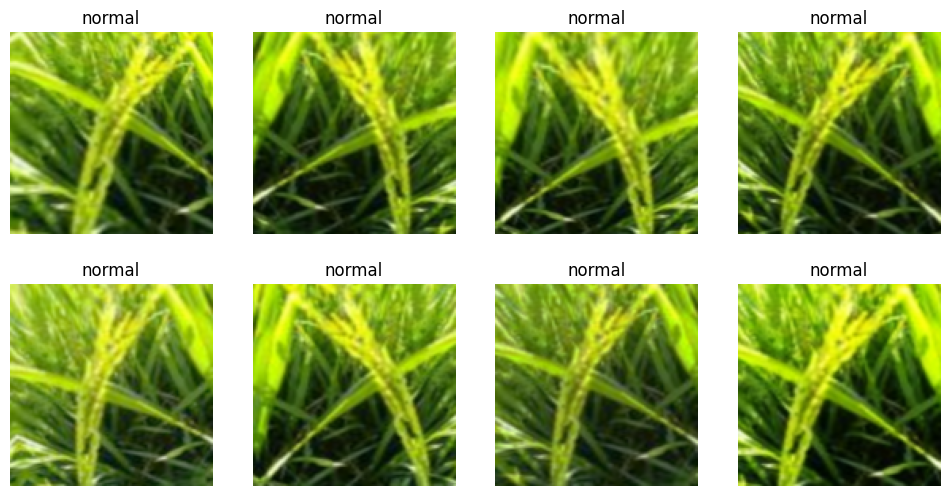

In [15]:
# lets look at what the data augmentation is doing
conv_learner.dls.show_batch(max_n=8, nrows=2, unique=True) # it's resizing, flipping, different brightness, etc

In [16]:
tta_preds, _ = conv_learner.tta(dl=val)

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


In [17]:
error_rate(tta_preds, targs) # that's a pretty significant improvement!

TensorBase(0.0591)

### Scaling Up for Submission 2
 - In this notebook we found a model that performs better + used test time augmentation to improve performance
 - Let's use the regular sized images and train for a good amount of epochs and submit that to see how we improved

In [18]:
trn_path = path/'train_images' # using the original training images

In [20]:
# recall that most of the images were 640 x 480 which is a 4:3 aspect ratio
# can resize our images to be larger while preserving the aspect ratio (by not making it square don't need to distort)

subm_model = train(arch,
                   itm_tfms = Resize((480, 360), method='squish'), # the two image sizes are (640*480) and (480*640), x_min = 480, y_min = .75*x_min = 360
                   btch_tfms = aug_transforms(size=(256, 192), min_scale=0.75), # still want to use augmentation so use smaller images for batches, but preserve aspect ratio
                   epochs=12
                   )

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(


epoch,train_loss,valid_loss,error_rate,time
0,1.119557,0.598707,0.185007,01:50


epoch,train_loss,valid_loss,error_rate,time
0,0.502756,0.274143,0.095627,01:52
1,0.389848,0.276911,0.089380,01:52
2,0.340687,0.295719,0.089380,01:52
3,0.292603,0.209005,0.068717,01:52
4,0.232689,0.189825,0.056223,01:50
5,0.184521,0.233698,0.063431,01:50
6,0.132882,0.166855,0.055262,01:52
7,0.097315,0.132528,0.035560,01:51
8,0.068247,0.123984,0.034599,01:51
9,0.045943,0.106991,0.031235,01:51


Our model seems to be much better than last time, let's submit this model and see how we do

In [21]:
# get the test images and predict over them
tst_files = get_image_files(path/'test_images').sorted()
tst_dl = subm_model.dls.test_dl(tst_files) # now use the same data transforms as we did for our model


preds, _ = subm_model.tta(dl=tst_dl)

In [23]:
preds, preds.shape # let's see how tta gives predictions so we can get these to the strings needed for submitting

(tensor([[1.7802e-04, 3.2101e-08, 2.1295e-06,  ..., 9.9979e-01, 6.1427e-06,
          1.0835e-07],
         [2.8607e-06, 2.4412e-05, 2.2754e-08,  ..., 7.8185e-06, 9.9993e-01,
          1.7273e-05],
         [3.1779e-08, 1.3253e-07, 6.4145e-07,  ..., 4.6211e-04, 7.9180e-06,
          8.4821e-08],
         ...,
         [8.2365e-10, 1.8035e-09, 1.9524e-08,  ..., 1.0144e-07, 1.0000e+00,
          4.0098e-08],
         [2.8507e-05, 9.9760e-01, 4.3141e-05,  ..., 6.1756e-04, 4.3285e-05,
          7.4368e-05],
         [2.6300e-12, 1.2746e-15, 1.2097e-11,  ..., 6.6258e-13, 1.3963e-12,
          3.3008e-11]]),
 torch.Size([3469, 10]))

In [24]:
# I think these are probabilities for each class, to be sure let's sum along that axis
preds.sum(1) # yep

tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000])

In [26]:
# ok so our prediction will then be the class with max probability:
idxs = preds.argmax(dim=1)

classes = subm_model.dls.vocab[idxs]
classes[:5]

(#5) ['hispa','normal','blast','blast','blast']

In [28]:
subm_df = pd.DataFrame({'image_id': [f.name for f in tst_files], 'label': classes})
subm_df.head()

,image_id,label
0,200001.jpg,hispa
1,200002.jpg,normal
2,200003.jpg,blast
3,200004.jpg,blast
4,200005.jpg,blast


In [29]:
subm_df.to_csv('submission2.csv', index=False)

if not iskaggle:
  from kaggle import api
  # api.competition_submit_cli('submission2.csv', 'second submission', comp) # commenting this out as now our first sub has been made

100%|██████████| 70.5k/70.5k [00:00<00:00, 112kB/s]


In [30]:
! kaggle competitions submissions -c paddy-disease-classification # wow our score is so much hihger

fileName         date                        description        status                     publicScore  privateScore  
---------------  --------------------------  -----------------  -------------------------  -----------  ------------  
submission2.csv  2025-04-09 16:22:24.407000  second submission  SubmissionStatus.COMPLETE  0.98231      0.98387       
subm.csv         2025-04-07 02:36:42.840000  first submission   SubmissionStatus.COMPLETE  0.87274      0.87327       


With this submission we are now right around the 125-150th spot, way better than our last submission which placed us at 520!